# Taller 04 - Reducción de Dimensiones y Clustering con Spotify
### Alumna: Abril Gabriela de los Angeles Sanchez Perez
### Bootcamp DataScience 202604

In [2]:
# *Bloque 1: Importacion de las librerias necesarias para el taller*
# Paso 1. Importacion de los datos para poder manejarlos en el taller
import pandas as pd
import numpy as np

# Paso 2. Para la visualizacion de los datos, usaré matplotlib y seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Paso 3. Importar librerías de machine learning para poder trabajar los datos. 
from sklearn.preprocessing import StandardScaler # Para preprocesar los datos
from sklearn.decomposition import PCA # Para la reduccion de dimensión de los datos
from sklearn.cluster import KMeans # Elegi Kmeans para el clustering ya que este es mas efectivo con la cantidad de datos que tengo.

# Paso adicional: Ignorar advertencias menores, para mantener la salida de info limpia.
import warnings
warnings.filterwarnings('ignore')

print ("OK importacion, Librerias cargadas correctamente")

OK importacion, Librerias cargadas correctamente


In [3]:
# Paso 4. Cargue del dataset desde la carpeta local. 

df = pd.read_csv('spotifydataset.csv')
print ("OK dataset cargado correctamente") 

# Paso adicional: Mirar cuantas filas y columnas obtuve con el cargue, para saber con cuantos datos trabajaré
print ("El dataset tiene ", df.shape[0], " filas y ", df.shape[1], " columnas.")

OK dataset cargado correctamente
El dataset tiene  1000  filas y  23  columnas.


In [4]:
df.head() # Para saber con que estoy trabajando. 

,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


In [6]:
# Nota: Esto lo hago para obtener con un mayor filtro solo el nombre de las columnas que tengo en el df
print(f"\n Columnas del dataset:")
print(df.columns.tolist())


 Columnas del dataset:
['Unnamed: 0', 'artist_name', 'genres', 'followers', 'artist_popularity', 'artist_url', 'track_name', 'album_name', 'release_date', 'duration_ms', 'explicit', 'track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


In [ ]:
# Bloque 2: Limpieza y Preparacion

"""
Estas son las columnas previamente definidas para trabajar en este bloque:
track_popularity
danceability
energy
key
loudness
mode
speechiness
acousticness
instrumentalness
liveness
valence
tempo
"""

# Paso 1: Encuadrar unicamente las columnas necesarias para hacer el análisis, previamente definidas. 

elementos_del_audio = [
    'track_popularity', 'danceability', 'energy',
    'key', 'loudness', 'mode', 'speechiness',
    'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]
# Paso 2 : Para poder trabajar con esto, necesito convertirlo en un dataframe y explorar como quedó
df_audio = df[elementos_del_audio]
print(f"Filas: {df_audio.shape[0]}")
df_audio.head()

Filas: 1000


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,89,0.645,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,85,0.795,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,83,0.506,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,80,0.650,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,79,0.787,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


In [ ]:
# Paso 3.1: Revisar datos nulos dentro de estas columnas
print(f"Datos nulos por columna:\n{df_audio.isnull().sum()}")

# Paso 3.2: Revision de datos duplicados dentro de las columnas
print(f"Datos duplicados: {df_audio.duplicated().sum()}")

Datos nulos por columna:
track_popularity    0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
dtype: int64
Datos duplicados: 7


In [ ]:
# Paso 4: Es necesario deshacerme de los datos que están duplicados (Ya que no existen nulos)
df_audio = df_audio.drop_duplicates()
print(f"Datos duplicados después de eliminar: {df_audio.duplicated().sum()}")

Datos duplicados después de eliminar: 0


In [ ]:
# Paso 5: Ahora sí, es momento de realizar las estandarización de estos datos. 
# Esto debido a que hay columnas con distintas escalas, ejemplo de esto:
# tempo (rango 0-200) y danceability (rango 0-1)

scaler = StandardScaler() # Para estandarizar los datos, es decir, llevarlos a una media de 0 y una desviación estándar de 1. 
df_audio_scaled = scaler.fit_transform(df_audio) # Esto me devuelve un array, por lo que lo convierto nuevamente a dataframe para poder trabajar con él.
print("OK datos estandarizados correctamente")

OK datos estandarizados correctamente


In [ ]:
# Bloque 3: Reducción de Dimensionalidad (PCA)
# El objetivo es disminuir estas variables a 2 para visualizarse en una grafica 2D

# Paso 1. Realizar PCA para reducir las variables de 12 a 2 principales. 

pca = PCA(n_components=2) # Esto me permite reducir a 2 componentes principales
df_audio_pca = pca.fit_transform(df_audio_scaled) # Aca solo construyo un array, es necesario convertirlo a dataframe.
print("OK PCA realizado correctamente")


OK PCA realizado correctamente


In [15]:
# Paso 2. Revisar la varianza y cuanto conservamos reduciendo los componentes a 2.

varianza = pca.explained_variance_ratio_ # Esto ayuda a explicar la varianza
print(f"Varianza explicada por componente:")
print(f"   PC1: {varianza[0]*100:.1f}%") # Esto explica el porcentaje de varianza conservado en el primer componente.
print(f"   PC2: {varianza[1]*100:.1f}%") # Esto explica el porcentaje de varianza conservado en el segundo componente.
print(f"   Total explicado: {varianza.sum()*100:.1f}%") # Esto explica el porcentaje total de varianza conservada al reducir a 2 componentes.

Varianza explicada por componente:
   PC1: 24.9%
   PC2: 12.7%
   Total explicado: 37.7%


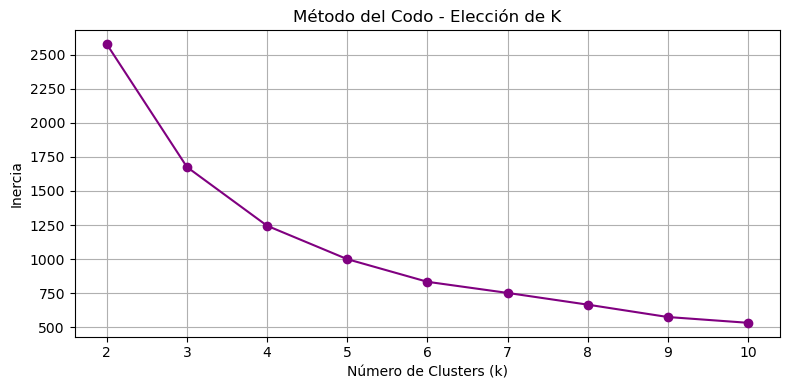

In [18]:
# Bloque 4: Modelado (Metodo utilizado: KMeans)

# Paso 1. Usaré el metodo del codo y probaré diferentes valores para el k

inercia = []
rango_k = range(2, 11)

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42)
    modelo.fit(df_audio_pca)
    inercia.append(modelo.inertia_)

# Paso 2. Graficaré la inercia para cada valor de k para visualizar el metodo del codo

plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercia, marker='o', color='purple')
plt.title('Método del Codo - Elección de K')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.xticks(rango_k)
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
# Una vez visualizada la grafica, se puede determinar que el 'k' se encuentra en 4, por lo que ahí hare el clustering para visualizarlo posteriormente.

# Paso 3. Aplicar el Kmeans con k=4 para obtener el cluster.
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(df_audio_pca)

# Paso 4. Guardar este cluster en el dataframe para posteriormente visualizarlo.
df_audio['cluster'] = kmeans.labels_ # Para agregar la columna en el df. 

print(f"K-Means aplicado con k=4")
print(f"\n Canciones por cluster:")
print(df_audio['cluster'].value_counts().sort_index()) # Para revisar cuantas canciones hay en cada cluster.

K-Means aplicado con k=4

 Canciones por cluster:
cluster
0    460
1     49
2    303
3    181
Name: count, dtype: int64


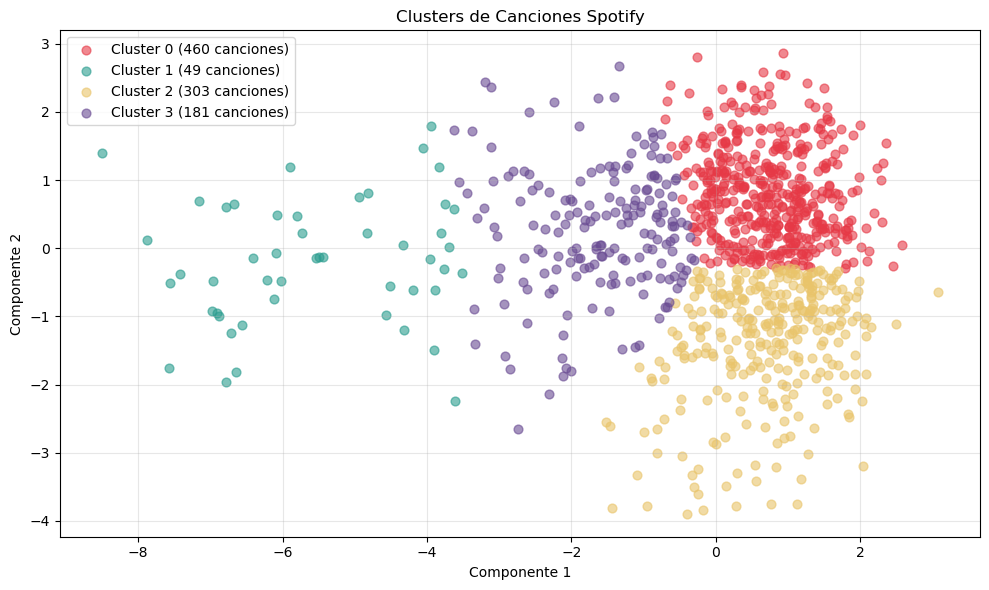

In [21]:
# Bloque 5: Visualización y Análisis.

# Grafico 1: Scatter plot coloreado por cluster en el espacio PCA
colores = ['#e63946', '#2a9d8f', '#e9c46a', '#6a4c93']
plt.figure(figsize=(10, 6))
for i in range(4):
    mask = df_audio['cluster'] == i
    plt.scatter(
        df_audio_pca[mask, 0],
        df_audio_pca[mask, 1],
        c=colores[i], label=f'Cluster {i} ({mask.sum()} canciones)',
        alpha=0.6, s=40
    )

plt.title('Clusters de Canciones Spotify')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Grafico 2. Perfil promedio por cluster. 
#¿Cuál será el promedio encontrado por cada cluster en estos audios?

perfil = df_audio.groupby('cluster')[['danceability','energy','loudness',
                                       'speechiness','acousticness',
                                       'instrumentalness','valence','tempo']].mean() 
# Esto me da el promedio de cada cluster para cada variable.

print(f"\n Perfil promedio por cluster:")
print(perfil.round(3))


 Perfil promedio por cluster:
         danceability  energy  loudness  speechiness  acousticness  \
cluster                                                              
0               0.724   0.691    -5.999        0.103         0.210   
1               0.356   0.185   -20.663        0.046         0.924   
2               0.514   0.811    -5.098        0.089         0.082   
3               0.556   0.456    -9.996        0.079         0.533   

         instrumentalness  valence    tempo  
cluster                                      
0                   0.002    0.638  115.605  
1                   0.685    0.256  112.818  
2                   0.063    0.434  138.075  
3                   0.117    0.415  115.362  


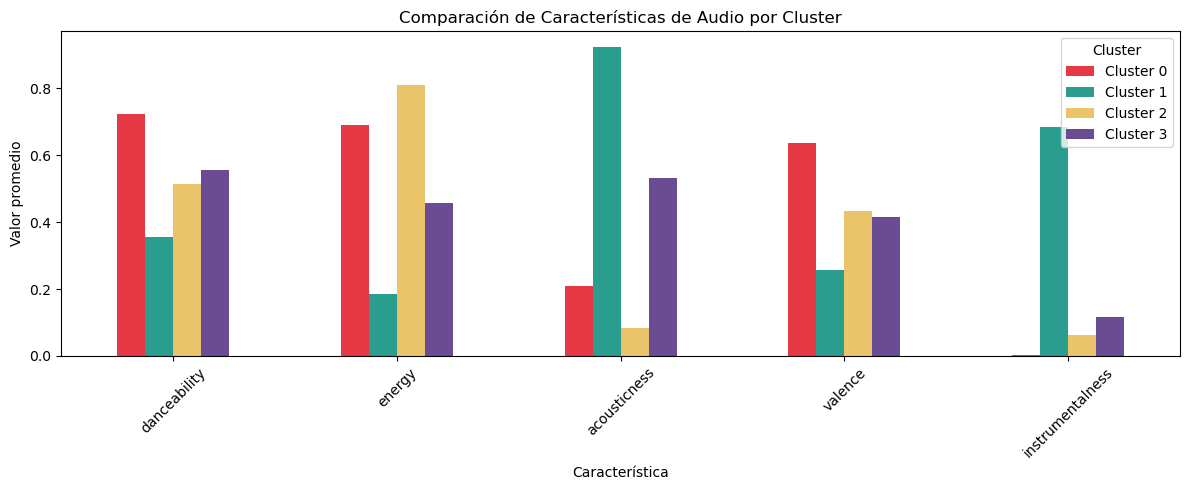

In [23]:
# Grafico 2. Comparación de características promedio por cluster por un grafico de Barras

perfil_plot = perfil[['danceability','energy','acousticness','valence','instrumentalness']]

perfil_plot.T.plot(kind='bar', figsize=(12, 5), color=colores)
plt.title('Comparación de Características de Audio por Cluster')
plt.xlabel('Característica')
plt.ylabel('Valor promedio')
plt.xticks(rotation=45)
plt.legend([f'Cluster {i}' for i in range(4)], title='Cluster')
plt.tight_layout()
plt.show()

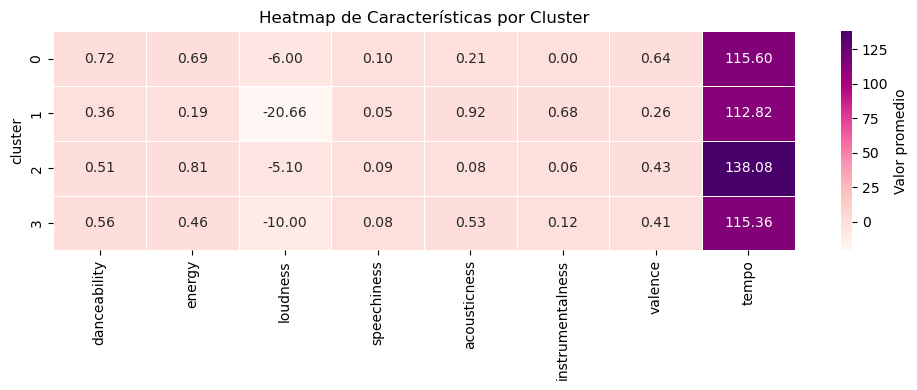

In [24]:
# Grafico 3. Heatmap para ver el perfil completo de cada cluster
plt.figure(figsize=(10, 4))
sns.heatmap(perfil, annot=True, fmt='.2f', cmap='RdPu',
            linewidths=0.5, cbar_kws={'label': 'Valor promedio'})
plt.title('Heatmap de Características por Cluster')
plt.tight_layout()
plt.show()

# Conclusiones del Taller. 

### *1. Hay una clara diferencia entre los cluster de cada audio*

En el análisis se pudieron evidenciar 4 grupos de audio con carácterísticas totalmente distintas. 

- Cluster 0 (Pop Bailable) = Son canciones con una alta danceability (0.72) y valence (0.64). Pueden ser anímicas y con mucho ritmo para poder bailar en cualquier celebración. 
- Cluster 1 (Acustica / Instrumentales) = Acousticness (0.92) e instrumentalness (0.68) muy altos, poca energía. Como para escuchar cuando uno hace tareas un lunes festivo por la noche (O sea yo hoy)
- Cluster 2 (Energético/Electrónico):Energía más alta (0.81) y tempo más rápido (138 BPM). Ideales para escuchar cuando uno hace ejercicios en el SmartFit.
- Cluster 3 (Baladas/Pop Suave):Acústico medio (0.53), baja energía (0.46). Canciones más melódicas y tranquilas como para escuchar un sabado mientras se limpia la casa. 

### *2. El PCA conservó el 37.7% de la varianza con solo 2 componentes*

Es un porcentaje algo bajo, pero sirve cuando estoy trabajando con 12 variables al tiempo que al mismo tiempo son muy distintas unas con las otras. Sin embargo, sirvió para identificar patrones y realizar gráficos. 

### *3. Aplicación al mundo real: Así es como funciona DJ Livi*

Usadas en el ámbito real así es como el algoritmo identifica que música combina con cual y permite generar playlists por género o incluso puede servir para alimentar a DJ Livi, la inteligencia artificial de Spotify, es por eso que a veces ella puede lanzar cosas como: Esto sirve para ir sobre ruedas o Esto suena como una música que podrías usar mientras cocina. Porque reune todas estas características y aprende a en que momento la gente es mas suceptible a escucharla y empieza a generar estas recomendaciones con los resultados.